In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Fertilizer Prediction.csv')
df

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea
...,...,...,...,...,...,...,...,...,...
94,25,50,32,Clayey,Pulses,24,0,19,28-28
95,30,60,27,Red,Tobacco,4,17,17,10-26-26
96,38,72,51,Loamy,Wheat,39,0,0,Urea
97,36,60,43,Sandy,Millets,15,0,41,DAP


In [3]:
df.columns

Index(['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

In [4]:
df["Fertilizer Name"].value_counts()

Fertilizer Name
Urea        22
DAP         18
28-28       17
14-35-14    14
20-20       14
17-17-17     7
10-26-26     7
Name: count, dtype: int64

In [5]:
df.nunique()

Temparature        14
Humidity           13
Moisture           41
Soil Type           5
Crop Type          11
Nitrogen           24
Potassium          13
Phosphorous        32
Fertilizer Name     7
dtype: int64

In [6]:
df.isnull().sum()

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      99 non-null     int64 
 1   Humidity         99 non-null     int64 
 2   Moisture         99 non-null     int64 
 3   Soil Type        99 non-null     object
 4   Crop Type        99 non-null     object
 5   Nitrogen         99 non-null     int64 
 6   Potassium        99 non-null     int64 
 7   Phosphorous      99 non-null     int64 
 8   Fertilizer Name  99 non-null     object
dtypes: int64(6), object(3)
memory usage: 7.1+ KB


array([[<Axes: title={'center': 'Temparature'}>,
        <Axes: title={'center': 'Humidity '}>],
       [<Axes: title={'center': 'Moisture'}>,
        <Axes: title={'center': 'Nitrogen'}>],
       [<Axes: title={'center': 'Potassium'}>,
        <Axes: title={'center': 'Phosphorous'}>]], dtype=object)

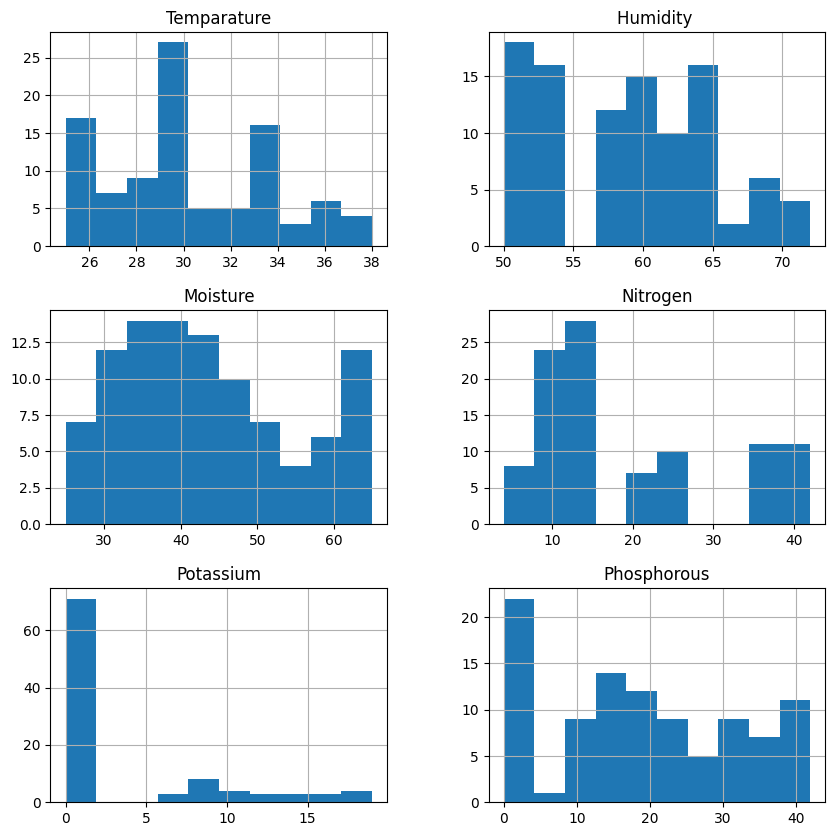

In [8]:
df.hist(figsize=(10,10))


In [9]:
y = df["Fertilizer Name"]
X = df.drop(["Fertilizer Name"],axis=1)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train shape:',X_train.shape)
print('y_train shape:',y_train.shape)
print('X_test shape:',X_test.shape)
print('y_test shape:',y_test.shape)

X_train shape: (79, 8)
y_train shape: (79,)
X_test shape: (20, 8)
y_test shape: (20,)


In [11]:
num_cols = [col for col in X_train.columns if X_train[col].dtypes!='O']
num_cols

['Temparature',
 'Humidity ',
 'Moisture',
 'Nitrogen',
 'Potassium',
 'Phosphorous']

In [12]:
cat_cols = [col for col in X_train.columns if X_train[col].dtypes=='O']
cat_cols

['Soil Type', 'Crop Type']

In [13]:
X_train[num_cols].head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
49,33,64,51,5,9,29
70,26,52,39,21,0,23
68,25,50,40,6,19,16
15,31,62,49,10,13,14
39,29,58,34,15,0,37


In [14]:
from sklearn.preprocessing import RobustScaler
r = RobustScaler()
r.fit(X_train[num_cols])

RobustScaler()

In [15]:
X_train_num_scaled = r.transform(X_train[num_cols])
X_train_num_scaled

array([[ 0.6       ,  0.4       ,  0.58823529, -0.61538462,  1.125     ,
         0.53658537],
       [-0.8       , -0.8       , -0.11764706,  0.61538462,  0.        ,
         0.24390244],
       [-1.        , -1.        , -0.05882353, -0.53846154,  2.375     ,
        -0.09756098],
       [ 0.2       ,  0.2       ,  0.47058824, -0.23076923,  1.625     ,
        -0.19512195],
       [-0.2       , -0.2       , -0.41176471,  0.15384615,  0.        ,
         0.92682927],
       [ 1.2       ,  0.8       , -0.17647059, -0.46153846,  1.125     ,
         0.58536585],
       [-0.2       , -0.2       , -0.47058824, -0.30769231,  0.875     ,
         0.58536585],
       [ 0.        ,  0.        , -0.05882353,  2.15384615,  0.        ,
        -0.87804878],
       [ 0.2       ,  0.2       ,  0.41176471,  0.07692308,  1.875     ,
        -0.29268293],
       [ 1.2       ,  0.8       ,  1.23529412,  0.15384615,  0.        ,
         1.07317073],
       [-1.        , -1.        , -0.52941176,  0.

In [16]:
X_test_num_scaled = r.transform(X_test[num_cols])
X_test_num_scaled

array([[ 0.8       ,  0.5       ,  1.35294118,  0.84615385,  0.        ,
         0.09756098],
       [-0.6       , -0.6       , -0.64705882,  0.        ,  0.        ,
        -0.24390244],
       [ 0.        ,  0.        , -0.82352941, -0.69230769,  2.125     ,
        -0.04878049],
       [-0.4       , -0.6       ,  1.41176471,  2.        ,  0.        ,
        -0.87804878],
       [ 1.2       ,  0.        ,  0.11764706,  0.15384615,  0.        ,
         1.12195122],
       [ 0.2       ,  0.2       ,  0.17647059,  0.61538462,  0.        ,
         0.48780488],
       [-0.6       , -0.7       , -0.35294118,  1.84615385,  0.        ,
        -0.87804878],
       [ 0.4       ,  0.2       , -0.41176471,  0.69230769,  0.        ,
         0.29268293],
       [-0.6       , -0.6       , -0.76470588,  0.        ,  0.        ,
         1.07317073],
       [-0.8       , -0.8       , -0.17647059,  1.84615385,  0.        ,
        -0.87804878],
       [ 0.        ,  0.        , -0.82352941, -0.

In [17]:
X_train[cat_cols].head()

,Soil Type,Crop Type
49,Sandy,Maize
70,Clayey,Pulses
68,Clayey,Pulses
15,Black,Sugarcane
39,Sandy,Millets


In [18]:
from sklearn.preprocessing import OneHotEncoder
o = OneHotEncoder(sparse=False, handle_unknown='ignore')
o.fit(X_train[cat_cols])

OneHotEncoder(handle_unknown='ignore', sparse=False, sparse_output=False)

In [19]:
X_train_cat_encoded = o.transform(X_train[cat_cols])
X_train_cat_encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [20]:
X_test_cat_encoded = o.transform(X_test[cat_cols])
X_test_cat_encoded

array([[1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0.,

In [21]:
X_train = pd.DataFrame(np.concatenate((X_train_num_scaled, X_train_cat_encoded), axis=1))
X_train

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.6,0.4,0.588235,-0.615385,1.125,0.536585,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.8,-0.8,-0.117647,0.615385,0.000,0.243902,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.0,-1.0,-0.058824,-0.538462,2.375,-0.097561,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.2,0.2,0.470588,-0.230769,1.625,-0.195122,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.2,-0.2,-0.411765,0.153846,0.000,0.926829,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,-0.4,-0.6,0.000000,1.769231,0.000,-0.878049,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
75,0.2,0.2,-0.529412,2.000000,0.000,-0.878049,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
76,-0.8,-0.8,-0.588235,0.076923,0.000,1.121951,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
77,1.2,0.8,0.000000,2.153846,0.000,-0.878049,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
X_test = pd.DataFrame(np.concatenate((X_test_num_scaled, X_test_cat_encoded), axis=1))
X_test

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.8,0.5,1.352941,0.846154,0.000,0.097561,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.6,-0.6,-0.647059,0.000000,0.000,-0.243902,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,-0.823529,-0.692308,2.125,-0.048780,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.4,-0.6,1.411765,2.000000,0.000,-0.878049,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.2,0.0,0.117647,0.153846,0.000,1.121951,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.2,0.2,0.176471,0.615385,0.000,0.487805,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,-0.6,-0.7,-0.352941,1.846154,0.000,-0.878049,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,0.4,0.2,-0.411765,0.692308,0.000,0.292683,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,-0.6,-0.6,-0.764706,0.000000,0.000,1.073171,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,-0.8,-0.8,-0.176471,1.846154,0.000,-0.878049,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit(y_train)
y_train_encoded = le.transform(y_train)

In [24]:
y_test_encoded = le.transform(y_test)
y_train_encoded

array([1, 4, 0, 2, 5, 1, 1, 6, 2, 5, 4, 4, 5, 5, 2, 1, 3, 6, 6, 4, 4, 6,
       4, 6, 5, 1, 4, 5, 4, 3, 4, 4, 2, 4, 3, 3, 5, 1, 0, 6, 3, 2, 6, 4,
       3, 3, 1, 3, 6, 0, 1, 2, 6, 1, 3, 1, 6, 1, 5, 0, 3, 5, 3, 5, 6, 2,
       1, 6, 6, 1, 5, 0, 5, 3, 6, 6, 5, 6, 3])

In [25]:
y_test_encoded

array([4, 3, 0, 6, 5, 4, 6, 4, 5, 6, 5, 4, 4, 1, 5, 6, 5, 6, 0, 6])

In [32]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train_encoded)
print('Training accuracy: ', lr.score(X_train,y_train_encoded))

Training accuracy:  1.0


In [33]:
y_pred = lr.predict(X_test)
y_pred

array([5, 3, 0, 6, 5, 4, 6, 4, 5, 6, 5, 4, 4, 1, 5, 6, 5, 6, 1, 6])

ValueError: X has 6 features, but LogisticRegression is expecting 22 features as input.